# E3 — The Beetle-Box (*Philosophical Investigations* §293)

*A working demonstration of Beetle-Box experiment **E3**, the centerpiece. Full
write-up and the options catalog: [`docs/e3_design.md`](../docs/e3_design.md).
Runs on CPU in ~a minute.*

**§293, in one breath.** Everyone has a box; each calls what's inside it a
"beetle"; no one can look into anyone else's box. Wittgenstein's claim is that
whatever is in the box **cancels out** of the public language — if "beetle" has a
public use, that use can't be as the name of the private object, because the
private object does no work.

**How we operationalize it.** A population plays a language-game while **we control
the boxes** — because we're the experimenters, we have the God's-eye view the
agents lack. Each agent gets a private per-trial signal (its "beetle") under one of
four conditions:

| condition | box contents | §293 role |
|---|---|---|
| `shared` | every agent encodes the state with the **same** code | a literally shared inner state |
| `divergent` | each encodes it with its **own** private code | the literal beetle-box: same game, incomparable private forms |
| `empty` | a constant (carries nothing) | no beetle |
| `noise` | random, independent of the state | a beetle that does no work |

The box is a real network input, so it *could* drive behavior. Whether it does —
and whether its private **form** (shared vs. divergent) matters — is then a
measured result, not an assumption (the "earnable cancellation" rule, `plan` §3.3).

We'll (1) compare all three games across the four conditions, (2) **watch** the
beetle-box exchange form, and (3) run the **no-leak guard** that keeps the result
honest.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from beetlebox.config import E3RunConfig, E3ExperimentConfig, BoxConfig
from beetlebox.harness import E3RunManager
from beetlebox.analysis.transcript import format_convention

warnings.filterwarnings("ignore")

OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
         "vermil": "#D55E00", "purple": "#CC79A7", "sky": "#56B4E9"}
plt.rcParams.update({
    "figure.figsize": (7.5, 4.4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 10,
})

CONDITIONS = ["shared", "divergent", "empty", "noise"]

def train(game, condition, steps=3000):
    cfg = E3RunConfig(seed=0)
    cfg.experiment = E3ExperimentConfig(game=game, num_steps=steps)
    cfg.box = BoxConfig(condition=condition, box_dim=16)
    mgr = E3RunManager(cfg)
    for _ in range(steps):
        mgr._train_step()
    return mgr, mgr.evaluate()
print("ready")

ready


## 1. All three games × four conditions

Beetle-Box is a **framework for exploration**: E3 ships three operationalizations
of §293, and the game is a config axis, not a fixed choice. We run each under all
four box conditions and compare. Watch how the *same apparatus* gives different
verdicts.

In [2]:
games = ["private_referent", "sensation_matching", "public_referent_aux"]
results = {g: {} for g in games}
for g in games:
    for c in CONDITIONS:
        _, acc = train(g, c)
        results[g][c] = acc
    ch = 0.5 if g == "sensation_matching" else 0.125
    row = "  ".join(f"{c}={results[g][c]:.2f}" for c in CONDITIONS)
    print(f"{g:20s} (chance {ch:.3f}):  {row}")

private_referent     (chance 0.125):  shared=1.00  divergent=0.87  empty=0.14  noise=0.12


sensation_matching   (chance 0.500):  shared=0.97  divergent=0.93  empty=0.50  noise=0.50


public_referent_aux  (chance 0.125):  shared=1.00  divergent=0.88  empty=0.77  noise=1.00


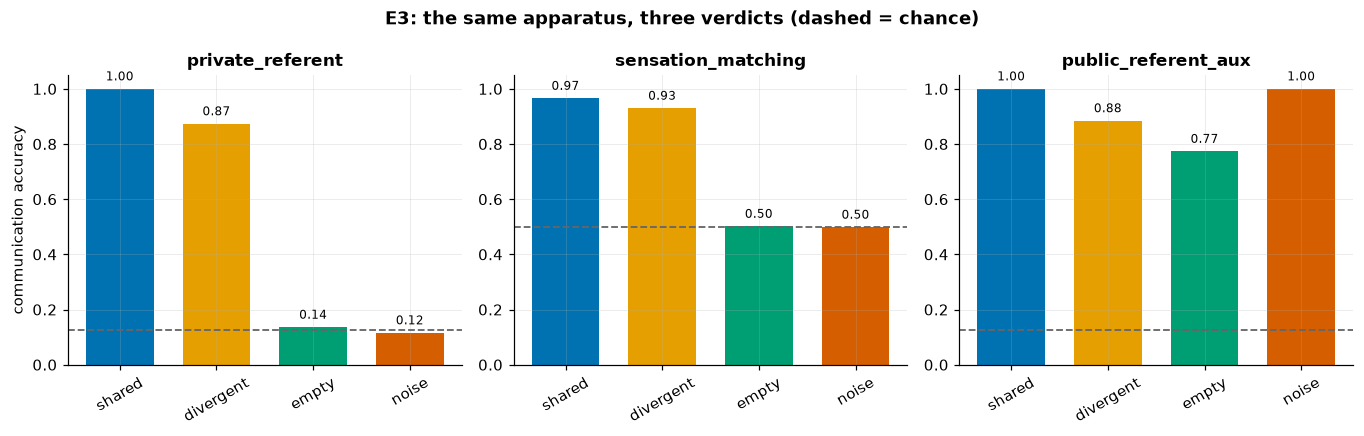

In [3]:
# Grouped bar chart: accuracy by condition, one panel per game (single y-axis each).
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0), dpi=110)
colors = [OKABE["blue"], OKABE["orange"], OKABE["green"], OKABE["vermil"]]
for ax, g in zip(axes, games):
    chance = 0.5 if g == "sensation_matching" else 0.125
    vals = [results[g][c] for c in CONDITIONS]
    bars = ax.bar(CONDITIONS, vals, color=colors, width=0.7)
    ax.axhline(chance, color="0.4", ls="--", lw=1.2)
    ax.set_ylim(0, 1.05); ax.set_title(g, fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8)
axes[0].set_ylabel("communication accuracy")
fig.suptitle("E3: the same apparatus, three verdicts (dashed = chance)",
             fontweight="bold")
fig.tight_layout(); plt.show()

Reading the three panels:

- **`private_referent`** (the centerpiece): informative boxes (`shared`,
  `divergent`) succeed while `empty`/`noise` sit at chance — coordination is
  **earnable**. `shared` is easier than `divergent` (which forces the receiver to
  learn a cross-code translation), but both work: the private *form* is not what
  makes or breaks the public game.
- **`sensation_matching`**: `shared` measurably beats `divergent`, both well above
  the 0.5 chance line, with `empty`/`noise` at chance — here a *shared* inner state
  genuinely helps (a result against the strong deflationary reading).
- **`public_referent_aux`** (control): high across the board — the referent is
  public to the sender, so the box is ignorable. This is what "the box doesn't
  matter" looks like when it truly doesn't.

## 2. Keeping it honest — the no-leak guard

A beetle-box result only means something if the **public message** is doing the
work. It's dangerously easy to build a game where an agent secretly reads its own
box and never communicates — in which case "the beetle drops out" is *rigged*, not
found (`plan` §3.3). (An earlier version of `private_referent` had exactly this
leak; see the design doc's history note.)

`channel_ablation()` decomposes which channel carries the signal: it re-measures
accuracy with the **message zeroed** and with the **receiver's boxes zeroed**. For
a valid result, zeroing the message must drop accuracy to chance.

In [4]:
mgr, _ = train("private_referent", "shared", steps=3000)
abl = mgr.channel_ablation()
print("private_referent / shared — channel ablation:")
print(f"  full communication      : {abl['full']:.3f}")
print(f"  MESSAGE zeroed          : {abl['message_zeroed']:.3f}   (must be ~chance {abl['chance']:.3f})")
print(f"  receiver boxes zeroed   : {abl['box_zeroed']:.3f}")
assert abl["message_zeroed"] <= abl["chance"] + 0.10, "LEAK: message is not load-bearing!"
print("\nPASS: with the message removed, accuracy collapses to chance ->")
print("      the public channel is genuinely carrying the meaning (no leak).")

private_referent / shared — channel ablation:
  full communication      : 1.000
  MESSAGE zeroed          : 0.117   (must be ~chance 0.125)
  receiver boxes zeroed   : 0.102

PASS: with the message removed, accuracy collapses to chance ->
      the public channel is genuinely carrying the meaning (no leak).


## 3. Watching the beetle-box exchange

Now the payoff: the **exchange itself**, for the centerpiece game. For each
referent we print what the sender says (from its private box) and what the receiver
guesses back (using the message to pick among candidates). Compare the conditions
side by side.

Read a row exactly as in E1: `referent → sender says <symbol> → receiver guesses
<referent> → result`. The difference from E1 is *why* it works — here the sender
only knows the referent through its **private box**, and under `empty` it is blind.

In [5]:
for cond in ["shared", "divergent", "empty"]:
    mgr, ev = train("private_referent", cond, steps=3000)
    conv = mgr.greedy_convention()
    print(f"### box condition: {cond}   (accuracy {ev:.3f}) ###")
    print(format_convention(conv["mapping"], conv["guesses"]))
    print()

### box condition: shared   (accuracy 1.000) ###
convention snapshot
  referent  sender says   receiver guesses   result
         0           s6                  0   [OK]
         1           s0                  1   [OK]
         2           s2                  2   [OK]
         3           s7                  3   [OK]
         4           s3                  4   [OK]
         5           s1                  5   [OK]
         6           s4                  6   [OK]
         7           s5                  7   [OK]
  8/8 referents correctly communicated



### box condition: divergent   (accuracy 0.873) ###
convention snapshot
  referent  sender says   receiver guesses   result
         0           s4                  0   [OK]
         1           s0                  1   [OK]
         2           s1                  2   [OK]
         3           s7                  3   [OK]
         4           s3                  4   [OK]
         5           s1                  2   [x]   <- collides with referent 2
         6           s5                  6   [OK]
         7           s2                  7   [OK]
  7/8 referents correctly communicated



### box condition: empty   (accuracy 0.136) ###
convention snapshot
  referent  sender says   receiver guesses   result
         0           s6                  0   [OK]
         1           s6                  0   [x]   <- collides with referent 0
         2           s6                  0   [x]   <- collides with referent 0
         3           s6                  0   [x]   <- collides with referent 0
         4           s6                  0   [x]   <- collides with referent 0
         5           s6                  0   [x]   <- collides with referent 0
         6           s6                  0   [x]   <- collides with referent 0
         7           s6                  0   [x]   <- collides with referent 0
  1/8 referents correctly communicated



- **`shared`** and **`divergent`**: the code forms either way — most referents are
  communicated. The sender's private encoding differs between these conditions, but
  the public game succeeds regardless: **the particular beetle drops out.**
- **`empty`**: total collapse. With no box, the sender is blind to the referent and
  emits the same symbol for everything — no amount of decoding can recover what was
  never sent. This is the floor that makes the success above *earnable*.

> Note on collisions: unlike E1, two referents sharing a symbol here isn't
> automatically a failure — but the no-leak guard (§2) already proved the message,
> not the receiver's own box, is what resolves them.

## What E3 does (and does not) license

E3 turns the core claim of §293 into a number. If empty/divergent-box agents
coordinate as fluently as shared-box agents, we have a working model of *the beetle
dropping out*; if a shared inner state measurably improves coordination
(`sensation_matching`), that counts against the strong deflationary reading. Either
way it does **not** settle whether the agents "have" inner states, or what those
states are like. The four conditions are our God's-eye control — the agents never
get one. (`plan/beetle-box.md` §4.3)

Score a saved condition sweep against the frozen pre-registration with
`python -m beetlebox.analysis.e3 <run_dir> ...`; see the fully-described
[exemplary run](../results/exemplary/e3_beetle_box/).